In [1]:
import numpy as np
import jax.numpy as jnp

import pandas as pd

import scipy as sp
from scipy.integrate import quad
from scipy.stats import multivariate_normal
import matplotlib.pyplot as plt

from herculens.Coordinates.pixel_grid import PixelGrid
from herculens.Instrument.noise import Noise
from herculens.Instrument.psf import PSF

from herculens.MassModel.mass_model import MassModel
from herculens.LightModel.light_model import LightModel
from herculens.LensImage.lens_image import LensImage

from herculens.MassModel.mass_model_multiplane import MPMassModel
from herculens.LightModel.light_model_multiplane import MPLightModel
from herculens.LensImage.lens_image_multiplane import MPLensImage

/opt/anaconda3/envs/herculensenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def initialise_lens_simulation(exposure_time=600, fov=2.0, telescope="hubble"):
    """
    Initialise a lens simulation corresponding to that of a given telescope
    """

    RES = {'hubble': 0.04, 'euclid': 0.1, 'JWST': 0.063} # arcseconds
    NOISE = {'hubble': 8.7e-3, 'euclid': 4.2e-3, 'JWST': 15.8e-3} # e- rms (downscaled by a factor of 1000 for signal-to-noise)
    PSF_FILE = {# (filename, supersampling factor)
    'hubble': ('hubble_psf.npy', 4), 
    'euclid': ('euclid_psf.npy', 1),
    'JWST': ('JWST_psf.npy', 7)
    }

    pix_scale = RES[telescope]
    noise = NOISE[telescope]
    psf_filename, supersampling_factor = PSF_FILE[telescope]
    psf = np.load(f"psf/{psf_filename}")

    nx, ny = (int(np.floor(fov/pix_scale)), int(np.floor(fov/pix_scale)))

    # set central pixel to (0,0)
    half_size_x = nx // 2
    half_size_y = ny // 2
    ra_at_xy_0 = - half_size_x * pix_scale
    dec_at_xy_0 = - half_size_y * pix_scale

    transform_pix2angle = pix_scale*np.eye(2)
    kwargs_pixel = {
        'nx': nx,
        'ny': ny,
        'ra_at_xy_0': ra_at_xy_0,
        'dec_at_xy_0': dec_at_xy_0,
        'transform_pix2angle': transform_pix2angle
    }

    # herculens' pixel grid class handles everything
    pixel_grid = PixelGrid(**kwargs_pixel)

    noise = Noise(nx, ny, background_rms=noise, exposure_time=exposure_time)
    psf = PSF(
        psf_type='PIXEL', 
        pixel_size=pix_scale, 
        kernel_point_source=psf, 
        kernel_supersampling_factor=supersampling_factor
        )
    
    return pixel_grid, noise, psf

In [3]:
def D_flat(z_i: float, z_j: float=0.0, *, Om=0.3089, Ol=0.6911, c=3e5, H0=67.74) -> float:
    """
    Calculate the angular diameter distance between two objects given a set of cosmological parameters.
    Assumes flat lambdaCDM.

    Parameters
    ----------
    z_i : float
        redshift of object i
    z_j : float
        redhsift of object j
    Om : float = 0.3
        Omega matter 
    Ol : float : 0.7
        Omega Lambda
    c : float = 3e5 [km/s]
        speed of light in a vacuum (in units of km/s)
    H0 : float = 67.8 [km/s/Mpc]
        Hubble parameter

    Returns 
    --------
    angular diameter distance in Mpc
    """

    def I(z):
        return 1/np.sqrt(Om * (1+z)**3 + Ol)
    
    val, _ = quad(I, z_i, z_j)
    return (c / H0) * val / (1 + z_j)   # Mpc

def eta_flat(z_lens: float, z_1: float, z_2: float, *, Om=0.3, Ol=0.7, H0=70) -> float:
    """
    Calculate the eta parameter given the redshifts of a lensing system. 
    Assumes flat lambdaCDM.

    Parameters
    ----------
    z_lens: float
        redshift of the lens
    z_1 : float
        reshift of source 1
    z_2 : float
        reshift of source 2

    Returns
    -------
    eta : float
        scale ratio of system
    """
    eta = D_flat(0, z_1) * D_flat(z_lens, z_2) / (D_flat(z_lens, z_1) * D_flat(0, z_2))
    return eta


In [4]:
import pandas as pd

# Load the CSV file into a DataFrame
df = pd.read_csv('data/slacs_data.csv')

# Display the first 5 rows of the DataFrame to verify
print(df.head())

zlens = df['zFG']
zsource = df['zBG']
status = df['Lens']


                 SDSS     zFG     zBG   Imag n_Imag        Name  L(V555)  \
0  000802.96-000408.2  0.4400  1.1924  18.65      d  J0008-0004     86.7   
1  002817.87-092934.3  0.0565  0.7146  13.75      s  J0028-0929     92.8   
2  002907.77-005550.5  0.2270  0.9313  17.09      d  J0029-0055     76.3   
3  003753.21-094220.1  0.1955  0.6322  16.26      s  J0037-0942    120.5   
4  004402.90+011312.6  0.1196  0.1965  15.73      s  J0044+0113     68.8   

      Re  Le2/LdV   b/a  ...  Mph Mul Lens n_Lens  Sloan       _RA      _DE  \
0   1.71    0.313  0.83  ...    E   S    A    NaN  Sloan   2.01233 -0.06894   
1  15.21    0.346  0.48  ...    L   S    X    NaN  Sloan   7.07446 -9.49286   
2   2.16    0.310  0.84  ...    E   S    A    NaN  Sloan   7.28237 -0.93069   
3   2.19    0.326  0.73  ...    E   S    A    NaN  Sloan   9.47171 -9.70558   
4   2.61    0.321  0.76  ...    E   S    A    NaN  Sloan  11.01208  1.22017   

   Plate    MJD  Fiber  
0    669  52559    156  
1    653  52145   

In [36]:
targets_mask = status == "A"  
targets_mask += status == "B"  

data = np.column_stack((zlens[targets_mask], zsource[targets_mask]))

mean_vector = np.mean(data, axis=0)
cov_matrix = np.cov(data, rowvar=False)

fitted_distribution = multivariate_normal(mean=mean_vector, cov=cov_matrix)

xmin, xmax = np.min(data[:,0]), np.max(data[:,0])
ymin, ymax = np.min(data[:,1]), np.max(data[:,1])
pm = 0.2

x = np.linspace(xmin, xmax, 1000)
y = np.linspace(ymin, ymax, 1000)
X, Y = np.meshgrid(x, y)

XY = np.column_stack([X.ravel(), Y.ravel()])
pdf_value = fitted_distribution.pdf(XY).reshape(X.shape)
pdf_value /= np.sum(pdf_value)

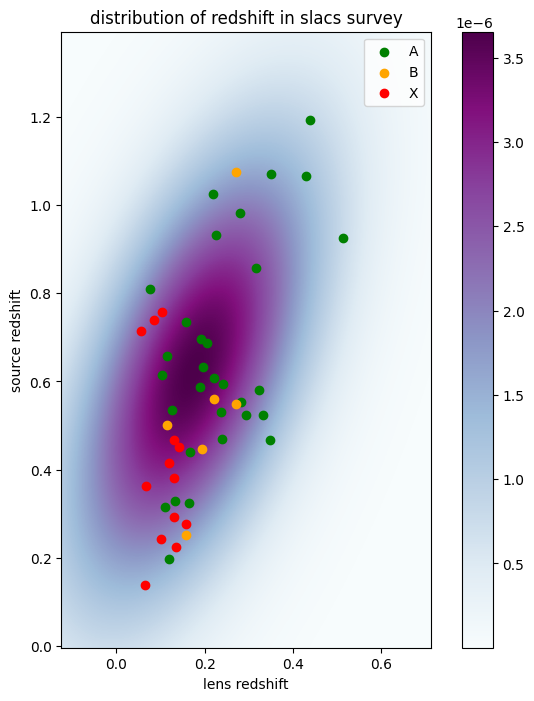

In [37]:
plt.figure(figsize=(8,8))

extent = [xmin-pm, xmax+pm, ymin-pm, ymax+pm]
plt.imshow(pdf_value, extent=extent, cmap='BuPu')
plt.colorbar()

plt.scatter(zlens[status=="A"], zsource[status=="A"], c='green', label='A')
plt.scatter(zlens[status=="B"], zsource[status=="B"], c='orange', label='B')
plt.scatter(zlens[status=="X"], zsource[status=="X"], c='red', label='X')

plt.title("distribution of redshift in slacs survey")
plt.legend()

plt.xlabel("lens redshift")
plt.ylabel("source redshift")

plt.savefig("figures_out/slac_dist.png")

plt.show()

Initialise pixel grid

In [7]:
eta = eta_flat(0.222, 0.609, 2.4)

pixel_grid, noise, psf = initialise_lens_simulation(fov=5, telescope='hubble')

xgrid, ygrid = pixel_grid.pixel_coordinates
x_axis = xgrid[0]
y_axis = ygrid[:, 0]
extent = pixel_grid.extent
x_grid, y_grid = np.meshgrid(x_axis, y_axis)

necessary mass and light models for each plane

In [8]:
lens_mass_model = MassModel(['EPL', 'SHEAR']) 
lens_light_model = LightModel(['SERSIC_ELLIPSE'])

source1_mass_model = MassModel(['SIS', 'SHEAR'])
source1_light_model = LightModel(['SERSIC_ELLIPSE'])  

source2_light_model = LightModel(['SERSIC_ELLIPSE'])

In [9]:
mp_mass_model = MPMassModel([lens_mass_model, source1_mass_model])
mp_light_model = MPLightModel([lens_light_model, source1_light_model, source2_light_model])

In [10]:
lens_EPL_kwargs = {
    'theta_E': 1.43,
    'gamma': 2.05,
    'e1': 0.0,
    'e2': 0.1,
    'center_x': 0.0,
    'center_y': 0.0
}
lens_shear_kwargs = {
    'gamma1': 0.0,
    'gamma2': -0.03,
    'ra_0': lens_EPL_kwargs['center_x'],
    'dec_0': lens_EPL_kwargs['center_y'],
}

source1_SIS_kwargs = {
    'theta_E': 0.1, # TODO
    'center_x': 0.0,
    'center_y': 0.0
}
source1_shear_kwargs = {
    'gamma1': 0.0,
    'gamma2': -0.03,
    'ra_0': source1_SIS_kwargs['center_x'],
    'dec_0': source1_SIS_kwargs['center_y'],
}

lens_mass_kwargs = [lens_EPL_kwargs, lens_shear_kwargs]
source1_mass_kwargs = [source1_SIS_kwargs, source1_shear_kwargs]

mp_mass_kwargs = [lens_mass_kwargs, source1_mass_kwargs]

# convergence
kappa_wrtlens, kappa_wrts1, kappa_wrts2 = mp_mass_model.kappa(x=x_grid, y=y_grid, eta_flat=eta, kwargs=mp_mass_kwargs)

# shear
gamma1, gamma2 = mp_mass_model.gamma(x=x_grid, y=y_grid, eta_flat=eta, kwargs=mp_mass_kwargs)
gamma_1_wrtlens, gamma_1_wrts1, gamma_1_wrts2 = gamma1
gamma_2_wrtlens, gamma_2_wrts1, gamma_2_wrts2 = gamma2

# magnification
mu_wrtlens, mu_wrts1, mu_wrts2 = 1/mp_mass_model.inverse_magnification(x=x_grid, y=y_grid, eta_flat=eta, kwargs=mp_mass_kwargs)

# deflection angle
# alpha_x, alpha_y = mp_mass_model.alpha(x=x_grid, y=y_grid, eta_flat=eta, kwargs=lens_mass_kwargs)
# alpha_x_wrtlens, alpha_x_wrts1, alpha_x_wrts2 = alpha_x
# alpha_y_wrtlens, alpha_y_wrts1, alpha_y_wrts2 = alpha_y 

Text(0.5, 1.0, 'convergence wrt s2')

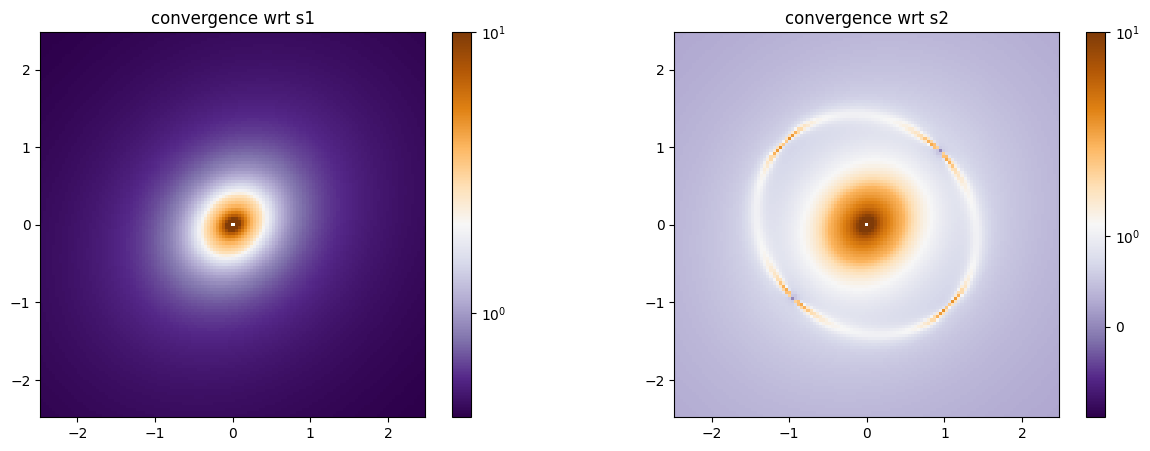

In [11]:
plt.figure(figsize=(15, 5))

plt.subplot(121)
plt.imshow(kappa_wrts1, origin='lower', cmap='PuOr_r', norm='symlog', extent=extent, vmax=10)
plt.colorbar()
plt.title('convergence wrt s1')

plt.subplot(122)
plt.imshow(kappa_wrts2, origin='lower', cmap='PuOr_r',  norm='symlog', extent=extent, vmin=-1, vmax=10)
plt.colorbar()
plt.title('convergence wrt s2')

Text(0.5, 1.0, 'magnification wrt s2')

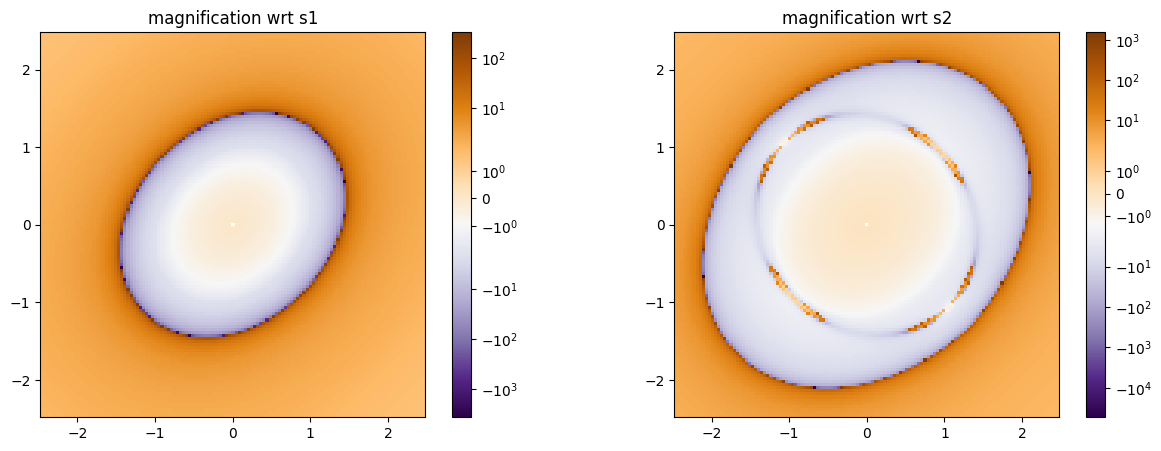

In [12]:
plt.figure(figsize=(15, 5))

plt.subplot(121)
plt.imshow(mu_wrts1, origin='lower', cmap='PuOr_r', norm='symlog', extent=extent)
plt.colorbar()
plt.title('magnification wrt s1')

plt.subplot(122)
plt.imshow(mu_wrts2, origin='lower', cmap='PuOr_r',  norm='symlog', extent=extent)
plt.colorbar()
plt.title('magnification wrt s2')

Light models

In [13]:
lens_sersic_kwargs = {
    'amp': 1.0,
    'R_sersic': 0.5,
    'n_sersic': 4.0, # n=4: de Vaucouleurs profile
    'e1': lens_EPL_kwargs['e2'],
    'e2': lens_EPL_kwargs['e2'],
    'center_x': lens_EPL_kwargs['center_x'],
    'center_y': lens_EPL_kwargs['center_y']
}
lens_light_kwargs = [lens_sersic_kwargs]

source1_sersic_kwargs = {
    'amp': 1.0,
    'R_sersic': 0.5,
    'n_sersic': 4.0, # n=4: de Vaucouleurs profile
    'e1': 0.0,
    'e2': 0.0,
    'center_x': source1_SIS_kwargs['center_x'],
    'center_y': source1_SIS_kwargs['center_y']
}
source1_light_kwargs = [source1_sersic_kwargs]

source2_sersic_kwargs = {
    'amp': 1.0,
    'R_sersic': 0.5,
    'n_sersic': 4.0, # n=4: de Vaucouleurs profile
    'e1': 0.0,
    'e2': 0.0,
    'center_x': 0.0,
    'center_y': 0.0
}
source2_light_kwargs = [source2_sersic_kwargs]

mp_light_kwargs = [lens_light_kwargs, source1_light_kwargs, source2_light_kwargs]

In [14]:
mp_lens_image = MPLensImage(
    grid_class=pixel_grid,
    psf_class=psf,
    noise_class=noise,
    mass_model_class=mp_mass_model,
    light_model_class=mp_light_model
    )

In [15]:
model_image = mp_lens_image.model(
    unconvolved=False, 
    kwargs_mass=mp_mass_kwargs, 
    kwargs_light=mp_light_kwargs, 
    eta_flat=jnp.array([eta])
    )

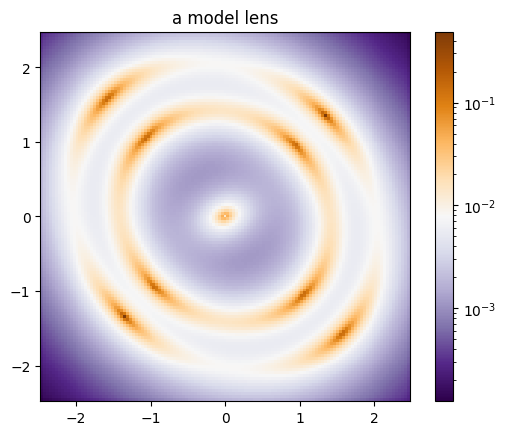

In [16]:
plt.imshow(model_image, origin='lower', cmap='PuOr_r',  extent=extent, norm='log')
plt.colorbar()
plt.title('a model lens')
plt.show()

In [17]:
simulated_image = mp_lens_image.simulation(
    kwargs_mass=mp_mass_kwargs, 
    kwargs_light=mp_light_kwargs, 
    eta_flat=jnp.array([eta])
    )

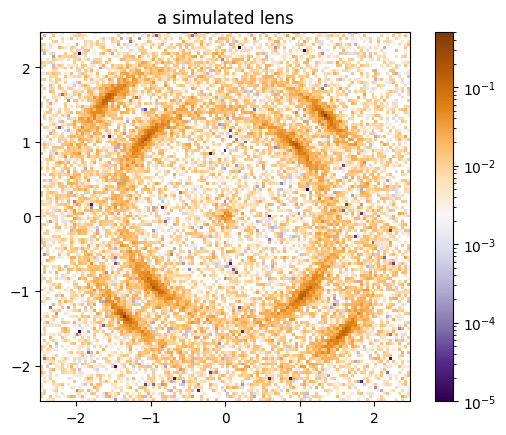

In [33]:
plt.imshow(simulated_image, origin='lower', cmap='PuOr_r',  extent=extent, norm='log', vmin=1e-5)
plt.colorbar()
plt.title('a simulated lens')
plt.savefig("figures_out/simulated_lens.png")
plt.show()